# B. 기준선 모델과 공통 평가

팀이 확정한 `train.csv`에서 5겹 교차검증을 수행한다. `test.csv`는 모든 설정을 확정하기 전에는 평가하지 않는다.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'processed' / 'train.csv').exists():
            return candidate
        if (candidate / 'data' / 'train.csv').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

ROOT = find_project_root()
DATA_DIR = ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed' if (DATA_DIR / 'processed' / 'train.csv').exists() else DATA_DIR
RESULT_ROOT = ROOT / 'outputs' if (ROOT / 'outputs').exists() else ROOT / 'results' / 'B'
SCRIPT_DIR = ROOT / 'scripts' if (ROOT / 'scripts').exists() else ROOT / 'members' / 'B'
TRAIN_PATH = PROCESSED_DIR / 'train.csv'
TEST_PATH = PROCESSED_DIR / 'test.csv'
print('Project root:', ROOT)

Project root: /Users/feel1p/Desktop/인공지능 공학/AI-Engineering-main


## 1. 팀 데이터 확인

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
summary = pd.DataFrame({
    'rows': [len(train), len(test)],
    'features': [train.shape[1] - 1, test.shape[1] - 1],
    'duplicates': [train.duplicated().sum(), test.duplicated().sum()],
    'missing': [train.isna().sum().sum(), test.isna().sum().sum()],
    'purchase_count': [train['Revenue'].astype(int).sum(), test['Revenue'].astype(int).sum()],
}, index=['train', 'test'])
display(summary)

,rows,features,duplicates,missing,purchase_count
train,9764,17,0,0,1526
test,2441,17,0,0,382


## 2. 5겹 교차검증 실행

로지스틱 회귀와 랜덤포레스트의 out-of-fold 예측을 생성한다. 이 단계에서 `test.csv`는 사용하지 않는다.

In [3]:
import sys
scripts_directory = str(SCRIPT_DIR)
if scripts_directory not in sys.path:
    sys.path.insert(0, scripts_directory)
from run_baseline import main
main(evaluate_test=False)

Team train: 9,764 rows, 17 features
Held-out test: 2,441 rows (not evaluated)

5-fold out-of-fold metrics at threshold 0.50
              model         evaluation  threshold  accuracy  precision  recall     f1  roc_auc  average_precision
      Random Forest 5-fold out-of-fold        0.5    0.9031     0.7003  0.6645 0.6819   0.9302             0.7469
Logistic Regression 5-fold out-of-fold        0.5    0.8541     0.5227  0.7608 0.6197   0.8995             0.6464

Top threshold candidates by F1 (candidates only, not final)
              model  threshold  accuracy  precision  recall     f1  roc_auc  average_precision
Logistic Regression       0.60    0.8822     0.6134  0.6664 0.6388   0.8995             0.6464
Logistic Regression       0.65    0.8864     0.6404  0.6232 0.6317   0.8995             0.6464
Logistic Regression       0.55    0.8710     0.5712  0.6992 0.6288   0.8995             0.6464
      Random Forest       0.45    0.8997     0.6677  0.7136 0.6899   0.9302             0.746

## 3. 기준 성능과 임계값 후보

In [4]:
cv_metrics = pd.read_csv(RESULT_ROOT / 'metrics' / 'cv_baseline_metrics.csv')
threshold_candidates = pd.read_csv(RESULT_ROOT / 'metrics' / 'cv_threshold_candidates.csv')
display(cv_metrics.style.format({
    'threshold': '{:.2f}', 'accuracy': '{:.3f}', 'precision': '{:.3f}',
    'recall': '{:.3f}', 'f1': '{:.3f}', 'roc_auc': '{:.3f}',
    'average_precision': '{:.3f}'
}))
display(threshold_candidates.style.format({
    'threshold': '{:.2f}', 'accuracy': '{:.3f}', 'precision': '{:.3f}',
    'recall': '{:.3f}', 'f1': '{:.3f}', 'roc_auc': '{:.3f}',
    'average_precision': '{:.3f}'
}))

,model,evaluation,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,Random Forest,5-fold out-of-fold,0.50,0.903,0.700,0.664,0.682,0.930,0.747
1,Logistic Regression,5-fold out-of-fold,0.50,0.854,0.523,0.761,0.620,0.900,0.646


,model,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,0.60,0.882,0.613,0.666,0.639,0.900,0.646
1,Logistic Regression,0.65,0.886,0.640,0.623,0.632,0.900,0.646
2,Logistic Regression,0.55,0.871,0.571,0.699,0.629,0.900,0.646
3,Random Forest,0.45,0.900,0.668,0.714,0.690,0.930,0.747
4,Random Forest,0.40,0.892,0.630,0.746,0.683,0.930,0.747
5,Random Forest,0.50,0.903,0.700,0.664,0.682,0.930,0.747


## 4. 발표용 그래프

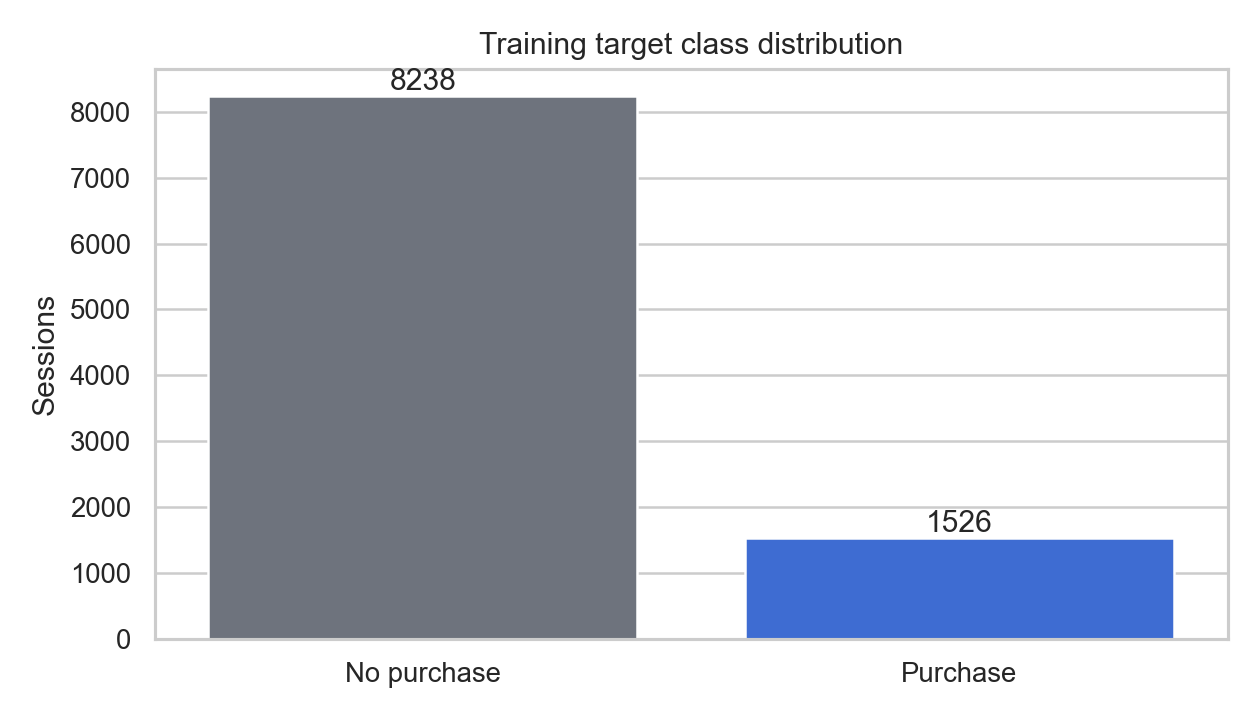

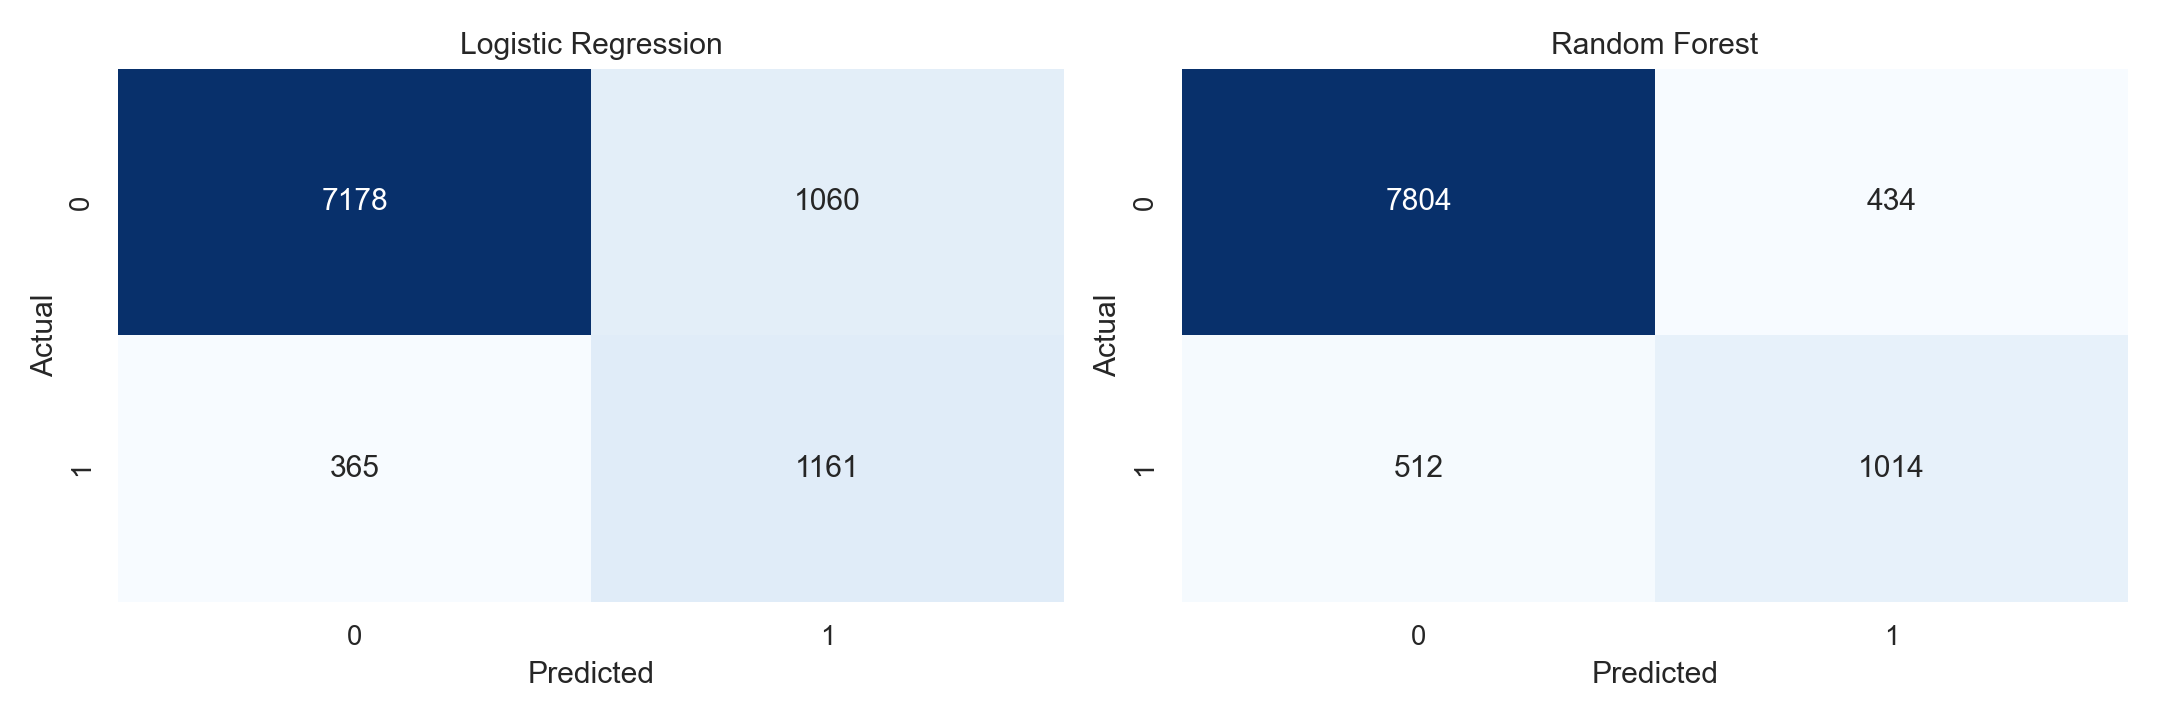

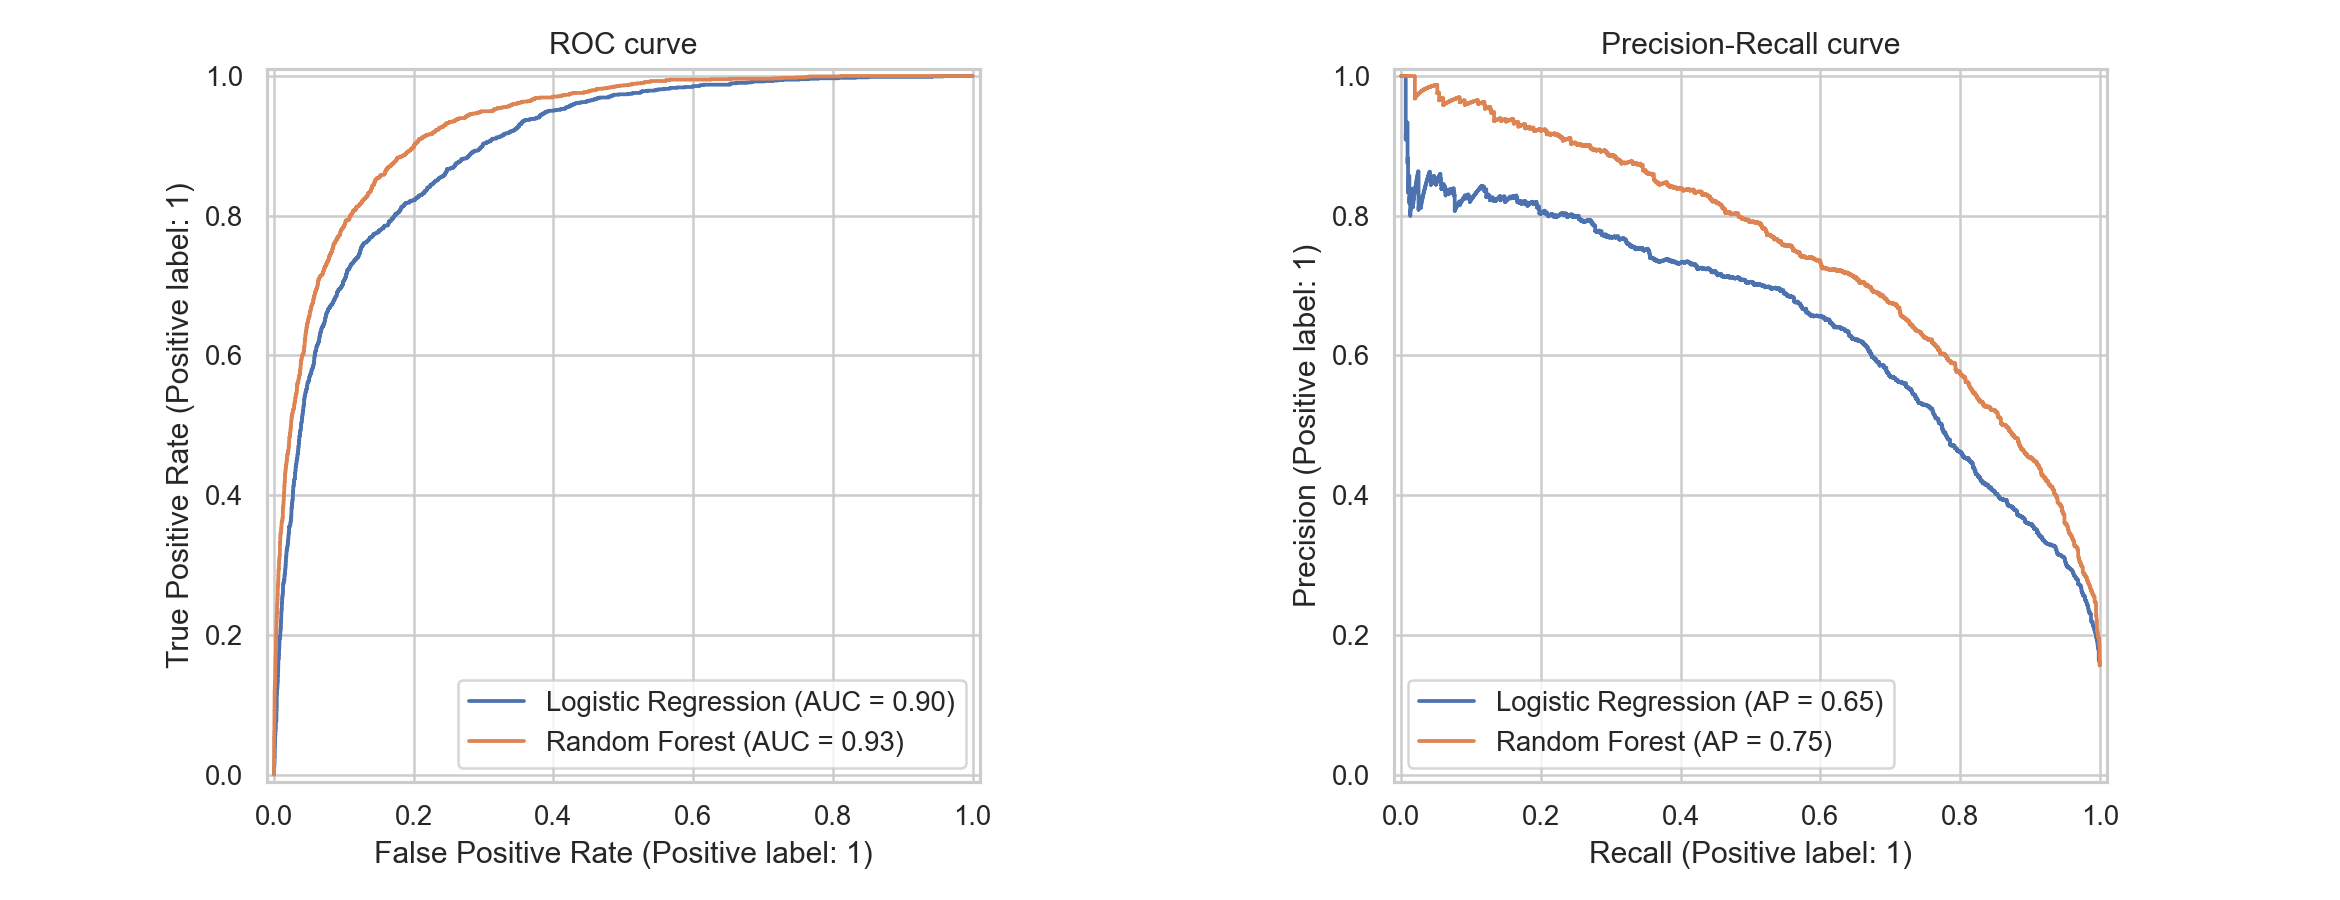

In [5]:
for filename in [
    'train_class_distribution.png',
    'cv_confusion_matrices.png',
    'cv_roc_pr_curves.png',
]:
    display(Image(filename=str(RESULT_ROOT / 'figures' / filename)))

## 5. 클래스 가중치와 PageValues 실험

클래스 가중치와 `PageValues` 특징이 성능에 미치는 영향을 같은 5겹 교차검증으로 비교한다.

              model    class_weight        feature_set  threshold  accuracy  precision  recall     f1  roc_auc  average_precision
Logistic Regression No class weight       All features        0.5    0.8822     0.7454  0.3742 0.4983   0.8898             0.6378
Logistic Regression        Balanced       All features        0.5    0.8541     0.5227  0.7608 0.6197   0.8995             0.6464
Logistic Regression        Balanced Without PageValues        0.5    0.6298     0.2570  0.7241 0.3794   0.7368             0.3132
      Random Forest No class weight       All features        0.5    0.9039     0.7570  0.5675 0.6487   0.9282             0.7509
      Random Forest        Balanced       All features        0.5    0.9031     0.7003  0.6645 0.6819   0.9302             0.7469
      Random Forest        Balanced Without PageValues        0.5    0.8407     0.4765  0.1927 0.2744   0.7734             0.3792


,model,class_weight,feature_set,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,No class weight,All features,0.50,0.882,0.745,0.374,0.498,0.890,0.638
1,Logistic Regression,Balanced,All features,0.50,0.854,0.523,0.761,0.620,0.900,0.646
2,Logistic Regression,Balanced,Without PageValues,0.50,0.630,0.257,0.724,0.379,0.737,0.313
3,Random Forest,No class weight,All features,0.50,0.904,0.757,0.567,0.649,0.928,0.751
4,Random Forest,Balanced,All features,0.50,0.903,0.700,0.664,0.682,0.930,0.747
5,Random Forest,Balanced,Without PageValues,0.50,0.841,0.476,0.193,0.274,0.773,0.379


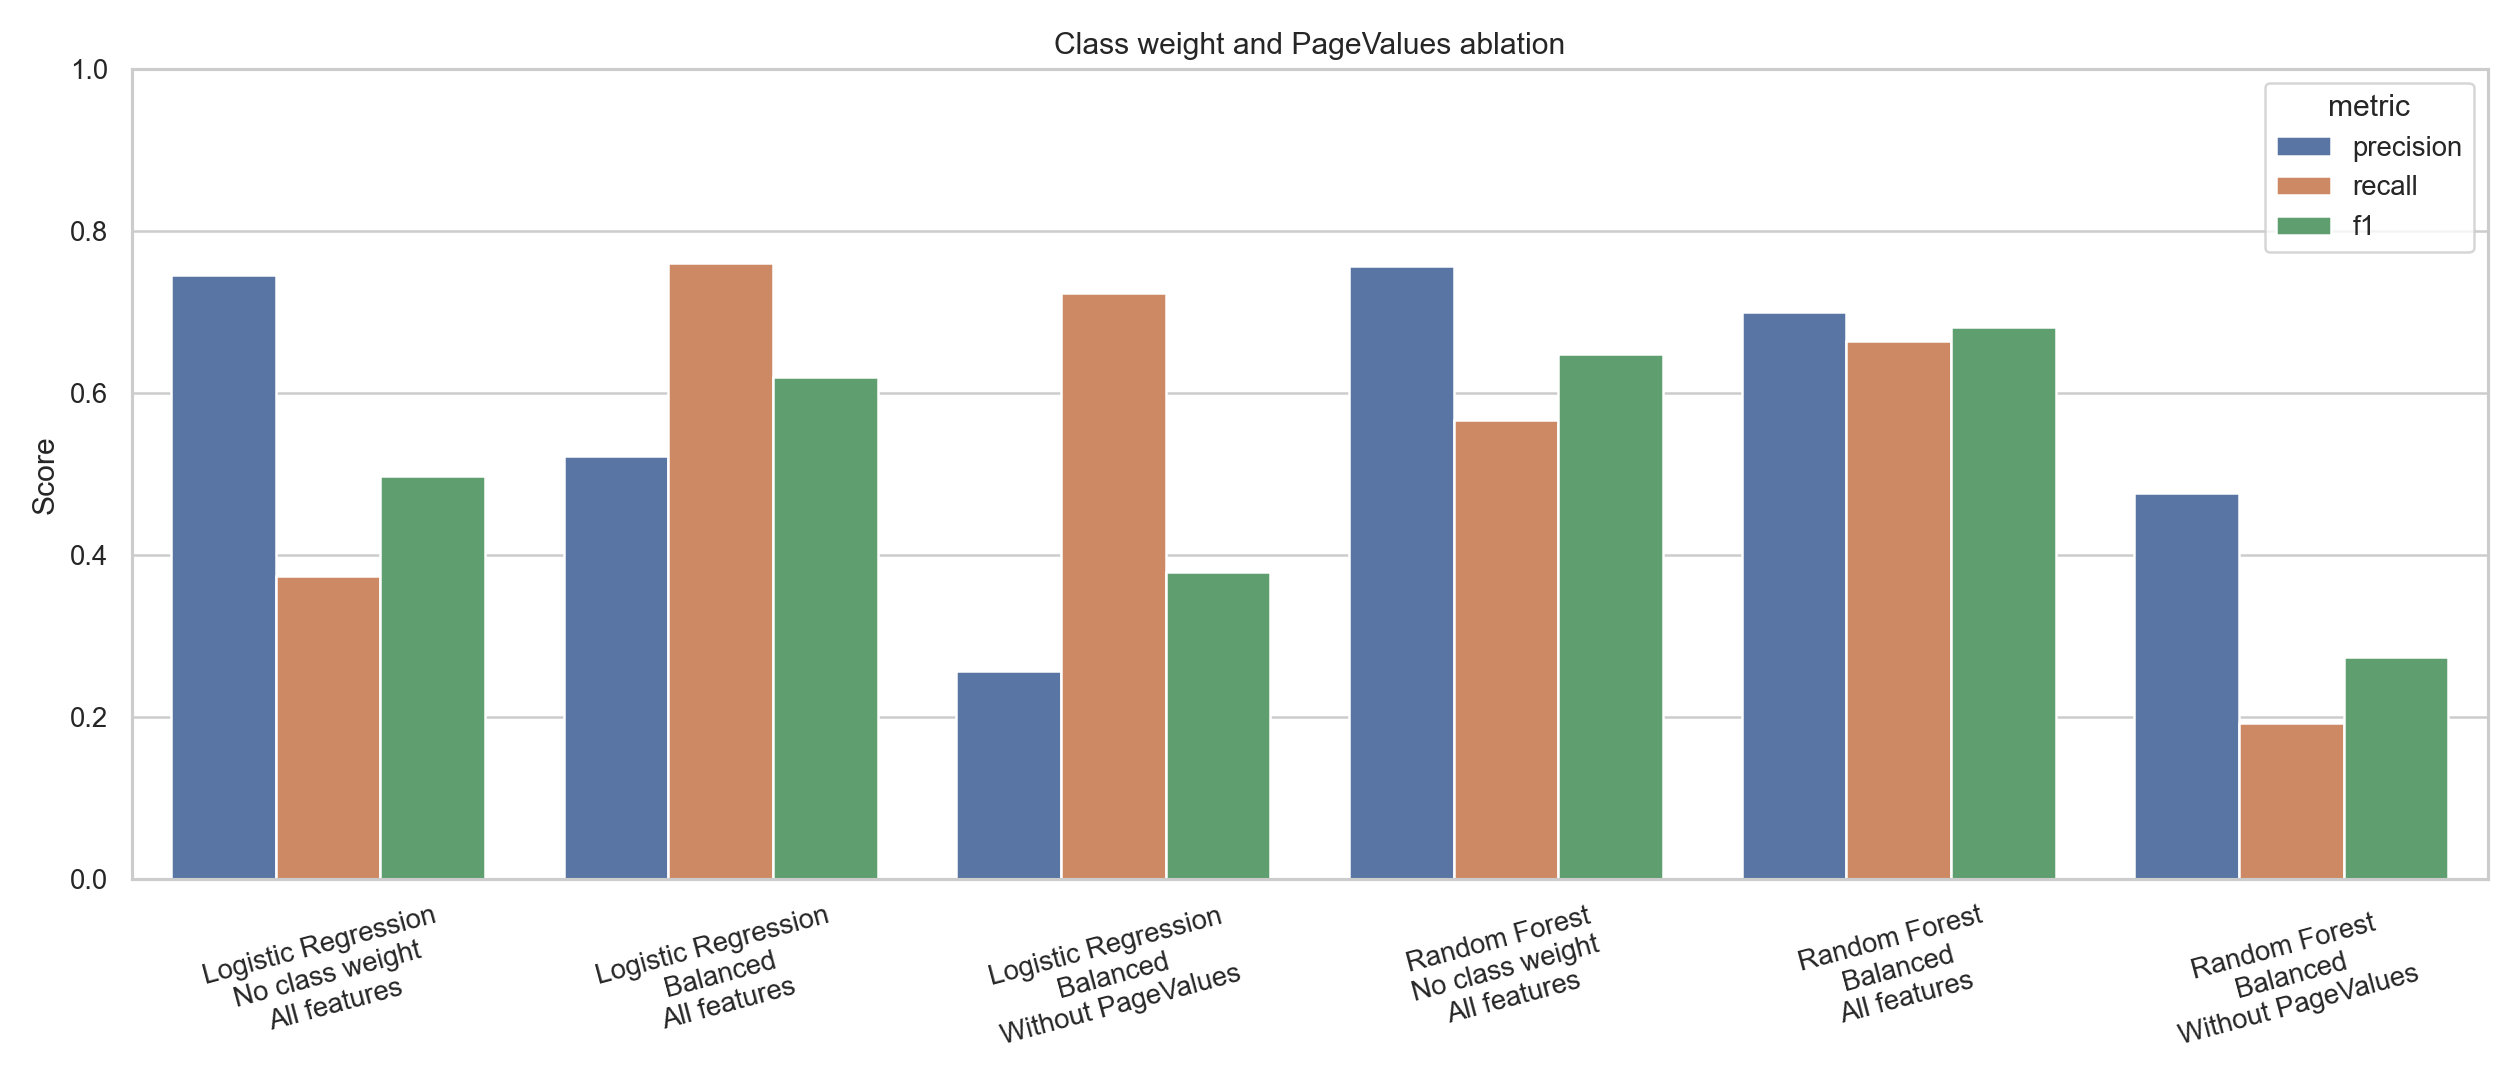

In [6]:
from run_ablation import main as run_ablation
run_ablation()
ablation_metrics = pd.read_csv(RESULT_ROOT / 'metrics' / 'cv_ablation_metrics.csv')
display(ablation_metrics.style.format({
    'threshold': '{:.2f}', 'accuracy': '{:.3f}', 'precision': '{:.3f}',
    'recall': '{:.3f}', 'f1': '{:.3f}', 'roc_auc': '{:.3f}',
    'average_precision': '{:.3f}'
}))
display(Image(filename=str(RESULT_ROOT / 'figures' / 'cv_ablation_comparison.png')))

## 6. 해석 메모

- 정확도는 미구매 클래스의 비율이 높아 단독으로 사용하지 않는다.
- 로지스틱 회귀는 구매 고객 Recall이 높지만 False Positive가 늘어날 수 있다.
- 랜덤포레스트는 전반적인 F1과 Average Precision이 더 높은지 확인한다.
- 임계값 후보는 교차검증 결과이며, 비즈니스 비용을 합의하기 전에 최종값으로 확정하지 않는다.
- 팀의 MLP 설정이 모두 확정되기 전에는 `--evaluate-test`를 실행하지 않는다.
- `PageValues` 제외 시 성능이 크게 하락하면 예측 시점에 이 특징을 알 수 있는지 A와 확인한다.